Loading data files...
Finding patients with procedure 9604...
Found 9882 hospital admissions with procedure 9604
Collected 9882 diagnoses
Processing text for word cloud...
Generating word cloud...


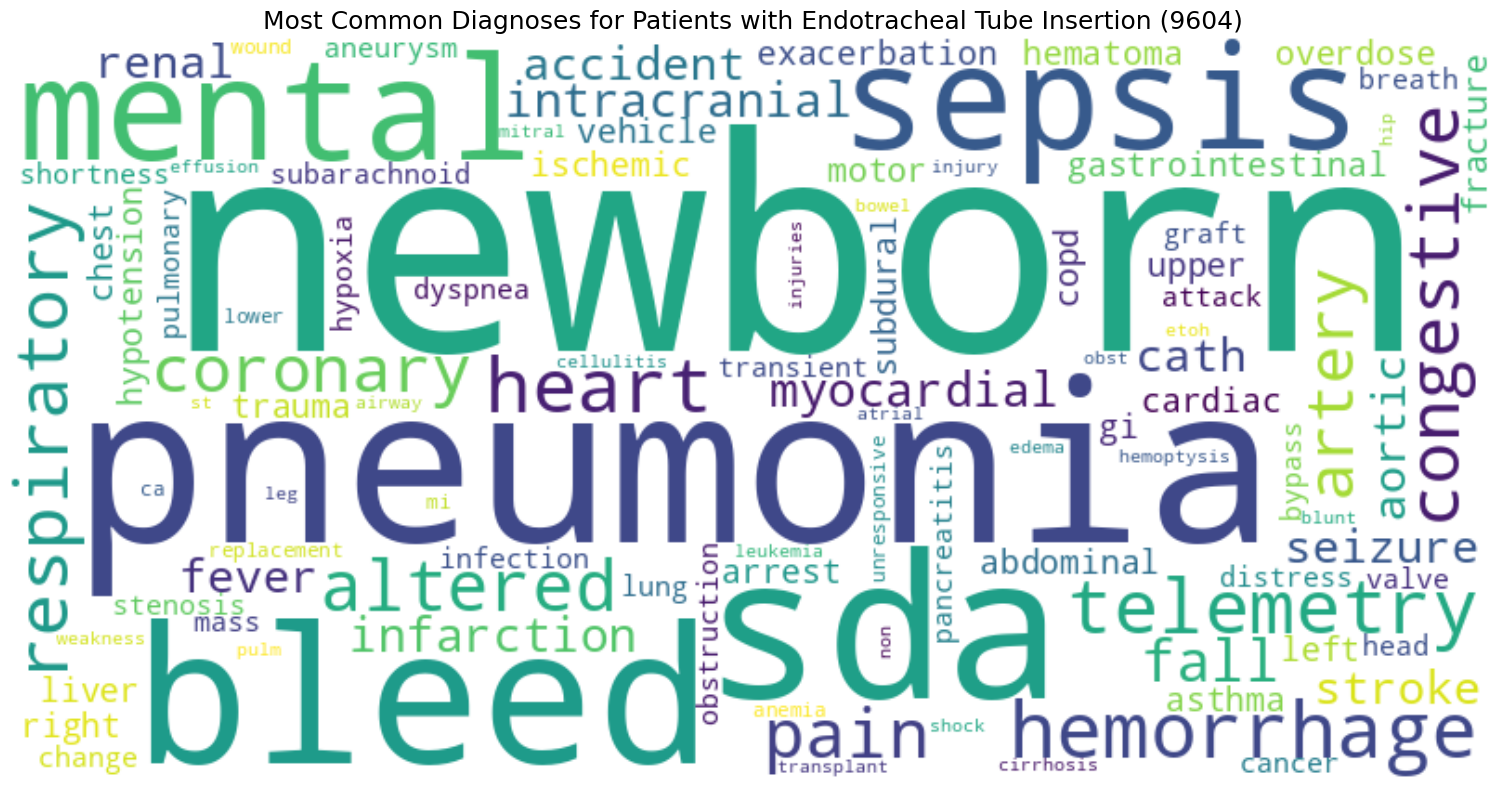


Top 20 most common diagnosis terms:
newborn: 1220
pneumonia: 606
bleed: 442
sepsis: 397
mental: 388
hemorrhage: 370
heart: 355
telemetry: 350
respiratory: 319
congestive: 310
altered: 308
pain: 299
coronary: 289
artery: 267
intracranial: 212
fall: 208
myocardial: 204
infarction: 202
aortic: 194
renal: 193

Examples of actual diagnoses:
- BENZODIAZEPINE OVERDOSE
- CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS GRAFT/SDA
- VENTRAL HERNIA/SDA
- GASTROINTESTINAL BLEED
- SEIZURE
- ALTERED MENTAL STATUS
- MASSIVE HEMOPTYSIS
- ? PULMONARY EMBOLUS WITH DESATURATION
- OVERDOSE
- NEWBORN

Saved all diagnoses to ./data/endotracheal_tube_diagnoses.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re
from collections import Counter

# Set your data path
DATA_PATH = './data'  # Update this to your actual data path

# Load the necessary data
print("Loading data files...")
admissions_df = pd.read_csv(f'{DATA_PATH}/ADMISSIONS.csv.gz')
procedures_df = pd.read_csv(f'{DATA_PATH}/PROCEDURES_ICD.csv.gz')

# Step 1: Find all patients who had the 9604 procedure (endotracheal tube insertion)
print("Finding patients with procedure 9604...")
tube_procedures = procedures_df[procedures_df['ICD9_CODE'] == 9604]
hadm_ids_with_tube = tube_procedures['HADM_ID'].unique()
print(f"Found {len(hadm_ids_with_tube)} hospital admissions with procedure 9604")

# Step 2: Get the diagnoses for these patients
print("Collecting diagnoses...")
tube_admissions = admissions_df[admissions_df['HADM_ID'].isin(hadm_ids_with_tube)]
diagnoses = tube_admissions['DIAGNOSIS'].dropna().tolist()
print(f"Collected {len(diagnoses)} diagnoses")

# Step 3: Process the text for the word cloud
def process_text(text_list):
    # Join all diagnoses into a single string
    text = ' '.join(text_list)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and digits
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    
    # Remove single-character words
    text = re.sub(r'\b\w\b', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("Processing text for word cloud...")
processed_text = process_text(diagnoses)

# Step 4: Define custom stopwords to remove common medical terms that aren't informative
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'disease', 'status', 'failure', 'disorder', 'syndrome', 'patient',
    'acute', 'chronic', 'without', 'with', 'due', 'secondary', 'primary',
    'history', 'unspecified', 'specified', 'type', 'state', 'post',
    'admission', 'diagnosis', 'other', 'nos', 'sp'
])

# Step 5: Generate the word cloud
print("Generating word cloud...")
wordcloud = WordCloud(
    background_color='white',
    max_words=100,
    width=800,
    height=400,
    stopwords=custom_stopwords,
    contour_width=3,
    contour_color='steelblue',
    collocations=False,  # Don't include bigrams
    random_state=42
).generate(processed_text)

# Step 6: Display the word cloud
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Diagnoses for Patients with Endotracheal Tube Insertion (9604)', fontsize=18)
plt.tight_layout()
plt.savefig(f'{DATA_PATH}/endotracheal_tube_diagnoses_wordcloud.png', dpi=300)
plt.show()

# Step 7: Show the top 20 most common words for additional context
words = re.findall(r'\b\w+\b', processed_text)
words = [word for word in words if word not in custom_stopwords and len(word) > 3]
word_counts = Counter(words)

print("\nTop 20 most common diagnosis terms:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

# Step 8: Show a few examples of actual diagnoses
print("\nExamples of actual diagnoses:")
for diagnosis in diagnoses[:10]:
    print(f"- {diagnosis}")

# Optional: Save the diagnoses to a CSV file for further analysis
pd.DataFrame(diagnoses, columns=['Diagnosis']).to_csv(
    f'{DATA_PATH}/endotracheal_tube_diagnoses.csv', index=False
)
print(f"\nSaved all diagnoses to {DATA_PATH}/endotracheal_tube_diagnoses.csv")